# MPC Szobahőmérséklet Szabályozó – Nappal/Éjszaka Termosztát

A szimuláció három fázisból áll:
- **t < 20 perc** → Nappal: 22 °C
- **20 ≤ t < 40 perc** → Éjszaka: 18 °C
- **t ≥ 40 perc** → Reggel: 24 °C

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# ── Szimulációs paraméterek ──────────────────────────────────────────────────
dt = 1.0          # időlépés [perc]
simulation_steps = 60

# ── Termikus modell paraméterei ──────────────────────────────────────────────
a = 0.05          # hőveszteségi együttható
b = 0.2           # fűtés hatása
T_out = 5.0       # külső hőmérséklet [°C]
T0 = 15.0         # kezdeti szobahőmérséklet [°C]

# ── MPC horizont ─────────────────────────────────────────────────────────────
N = 10

# ── Nappal-éjszaka referencia ütemterv ───────────────────────────────────────
def get_reference(t):
    """Visszaadja az aktuális célhőmérsékletet az időlépés alapján."""
    if t < 20:
        return 22.0   # Nappal
    elif t < 40:
        return 18.0   # Éjszaka
    else:
        return 24.0   # Reggel

In [3]:
# ── MPC vezérlő ──────────────────────────────────────────────────────────────
def mpc_controller(current_temp, t_current):
    """
    MPC optimalizáció az aktuális hőmérséklettől és időlépéstől indulva.
    A horizonton belül is követi a változó referenciát.
    """
    u = cp.Variable(N)
    T = cp.Variable(N + 1)

    constraints = [T[0] == current_temp]
    cost = 0

    for k in range(N):
        # Jövőbeli referencia a horizonton belül
        T_ref_k = get_reference(t_current + k)

        # Rendszerdinamika
        constraints += [
            T[k + 1] == T[k] + dt * (
                -a * (T[k] - T_out) + b * u[k]
            )
        ]

        # Beavatkozó jel korlátok
        constraints += [
            u[k] >= 0,
            u[k] <= 100
        ]

        # Költségfüggvény: tracking hiba + vezérlési energia
        cost += cp.square(T[k] - T_ref_k)   # tracking súlya: 1
        cost += 0.01 * cp.square(u[k])       # energia-takarékosság

    problem = cp.Problem(cp.Minimize(cost), constraints)
    problem.solve()

    return u.value[0]

In [4]:
# ── Szimuláció ───────────────────────────────────────────────────────────────
temperature = T0

temperature_history = []
control_history     = []
reference_history   = []
time_history        = []

for t in range(simulation_steps):
    T_ref = get_reference(t)

    control = mpc_controller(temperature, t)

    temperature = temperature + dt * (
        -a * (temperature - T_out) + b * control
    )

    temperature_history.append(temperature)
    control_history.append(control)
    reference_history.append(T_ref)
    time_history.append(t)

print("Szimuláció kész.")

Szimuláció kész.


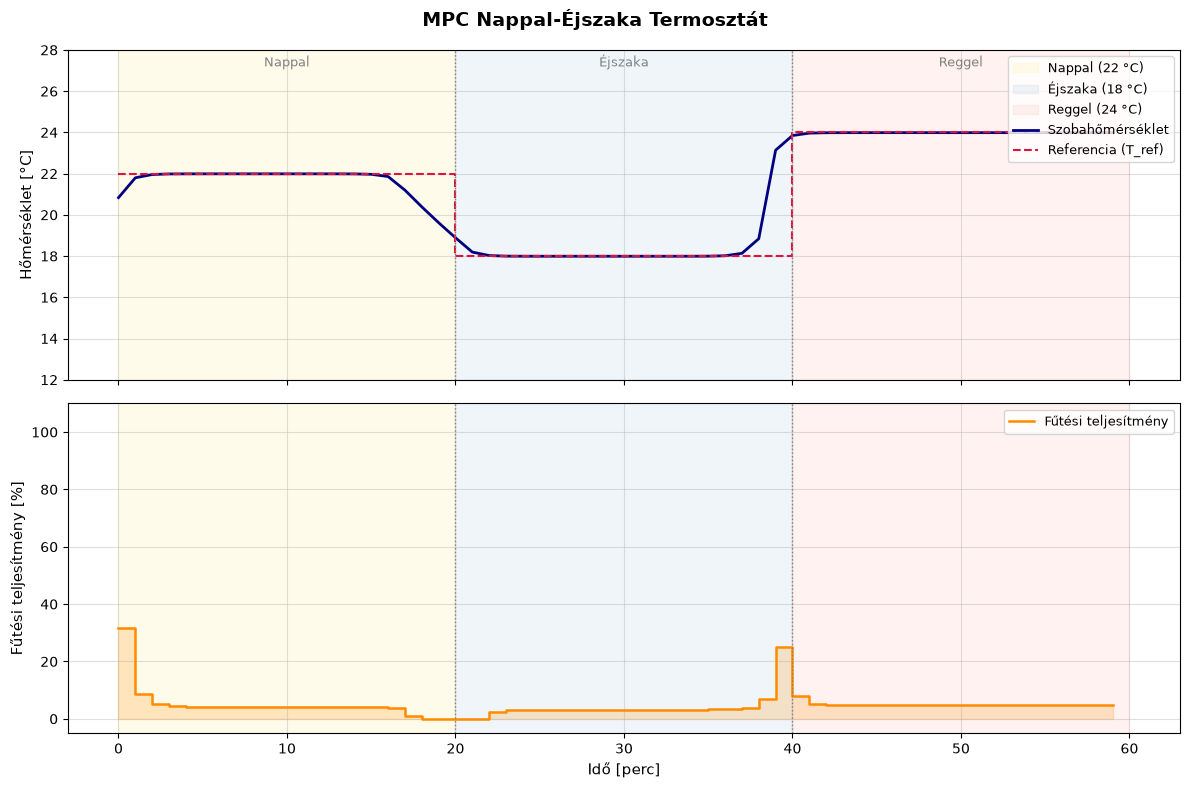

Grafikon mentve.


In [5]:
# ── Hőmérséklet grafikon ──────────────────────────────────────────────────────

from pathlib import Path


fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle("MPC Nappal-Éjszaka Termosztát", fontsize=14, fontweight="bold")

# ─ Felső panel: hőmérséklet ─
ax1 = axes[0]

# Fázis hátterek
ax1.axvspan(0,  20, alpha=0.08, color="gold",       label="Nappal (22 °C)")
ax1.axvspan(20, 40, alpha=0.08, color="steelblue",  label="Éjszaka (18 °C)")
ax1.axvspan(40, 60, alpha=0.08, color="tomato",     label="Reggel (24 °C)")

ax1.plot(time_history, temperature_history,
         color="navy", linewidth=2, label="Szobahőmérséklet")
ax1.step(time_history, reference_history,
         where="post", color="crimson", linewidth=1.5,
         linestyle="--", label="Referencia (T_ref)")

ax1.set_ylabel("Hőmérséklet [°C]", fontsize=11)
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(True, alpha=0.4)
ax1.set_ylim(12, 28)

# Fázis jelölők
for x, label in [(10, "Nappal"), (30, "Éjszaka"), (50, "Reggel")]:
    ax1.text(x, 27.2, label, ha="center", fontsize=9, color="gray")

# ─ Alsó panel: vezérlőjel ─
ax2 = axes[1]

ax2.axvspan(0,  20, alpha=0.08, color="gold")
ax2.axvspan(20, 40, alpha=0.08, color="steelblue")
ax2.axvspan(40, 60, alpha=0.08, color="tomato")

ax2.step(time_history, control_history,
         where="post", color="darkorange", linewidth=1.8, label="Fűtési teljesítmény")
ax2.fill_between(time_history, control_history,
                 step="post", alpha=0.2, color="darkorange")

ax2.set_xlabel("Idő [perc]", fontsize=11)
ax2.set_ylabel("Fűtési teljesítmény [%]", fontsize=11)
ax2.set_ylim(-5, 110)
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, alpha=0.4)

# Fázishatár vonalak
for ax in axes:
    ax.axvline(20, color="gray", linewidth=1, linestyle=":")
    ax.axvline(40, color="gray", linewidth=1, linestyle=":")

plt.tight_layout()
output_file = Path.cwd() / "mpc_daynight_thermostat1.png"
plt.savefig(output_file, dpi=150, bbox_inches="tight")
plt.show()
print("Grafikon mentve.")

In [6]:
# ── Összefoglaló statisztikák fázisonként ────────────────────────────────────
phases = [
    ("Nappal  (t=0–19)",  0,  20, 22.0),
    ("Éjszaka (t=20–39)", 20, 40, 18.0),
    ("Reggel  (t=40–59)", 40, 60, 24.0),
]

print(f"{'Fázis':<25} {'T_ref':>6} {'T_átlag':>8} {'Max hiba':>10} {'Fűtés átlag':>13}")
print("-" * 65)

for name, t_start, t_end, ref in phases:
    T_slice = temperature_history[t_start:t_end]
    u_slice = control_history[t_start:t_end]
    mean_T  = np.mean(T_slice)
    max_err = np.max(np.abs(np.array(T_slice) - ref))
    mean_u  = np.mean(u_slice)
    print(f"{name:<25} {ref:>6.1f} {mean_T:>8.2f} {max_err:>10.2f} {mean_u:>13.1f}%")

Fázis                      T_ref  T_átlag   Max hiba   Fűtés átlag
-----------------------------------------------------------------
Nappal  (t=0–19)            22.0    21.67       2.38           5.3%
Éjszaka (t=20–39)           18.0    18.36       5.14           4.2%
Reggel  (t=40–59)           24.0    23.98       0.15           4.9%
